In [1]:
!pip install mtcnn -q

(mtcnn is used for detecting faces in images)

In [2]:
from google.colab import files
files.upload()

Saving kaggle(2).json to kaggle(2) (1).json


{'kaggle(2) (1).json': b'{"username":"mslakshmitharani","key":"0e97fae94085fea5c26a2ac804ee233b"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip -q utkface-new.zip -d UTKFace

replace UTKFace/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
import os
for root, dirs, files in os.walk("UTKFace"):
    jpgs = [f for f in files if f.endswith(".jpg")]
    if jpgs:
        print(f"Found {len(jpgs)} images in: {root}")
        break


Found 23708 images in: UTKFace/utkface_aligned_cropped/UTKFace


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models


In [8]:
import os
for root, dirs, files in os.walk("UTKFace"):
    jpgs = [f for f in files if f.endswith(".jpg")]
    if jpgs:
        print(f"Found {len(jpgs)} images in: {root}")
        break

Found 23708 images in: UTKFace/utkface_aligned_cropped/UTKFace


1} Loading the Dataset and balancing it

In [9]:
DATA_DIR = "UTKFace/utkface_aligned_cropped/UTKFace"

records = []
for fname in os.listdir(DATA_DIR):
    if not fname.endswith(".jpg"):
        continue
    parts = fname.split("_")
    if len(parts) < 3:
        continue
    try:
        age    = int(parts[0])
        gender = int(parts[1])
        if 1 <= age <= 90:
            records.append((os.path.join(DATA_DIR, fname), age, gender))
    except:
        continue

print(f"Total images loaded: {len(records)}")


from collections import defaultdict
import random

buckets = defaultdict(list)
for path, age, gender in records:
    if age <= 20:
        buckets["0-20"].append((path, age, gender))
    elif age <= 40:
        buckets["21-40"].append((path, age, gender))
    elif age <= 60:
        buckets["41-60"].append((path, age, gender))
    else:
        buckets["61-90"].append((path, age, gender))

TARGET = 2500
balanced_records = []
for k, v in buckets.items():
    if len(v) >= TARGET:
        balanced_records.extend(random.sample(v, TARGET))
    else:
        oversampled = v * (TARGET // len(v) + 1)
        balanced_records.extend(oversampled[:TARGET])

random.shuffle(balanced_records)
print(f"Balanced dataset: {len(balanced_records)} images")

records = balanced_records

Total images loaded: 23621
Balanced dataset: 10000 images


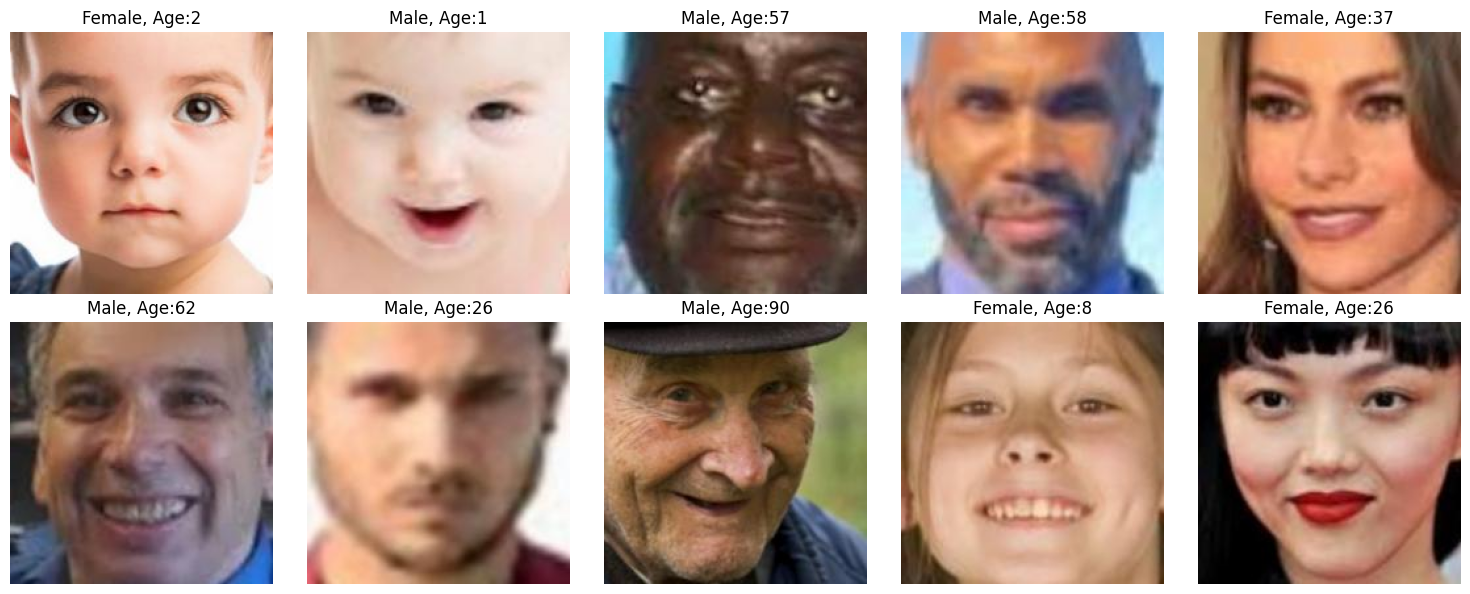

In [10]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
samples = random.sample(records, 10)

for ax, (path, age, gender) in zip(axes.flatten(), samples):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{'Male' if gender==0 else 'Female'}, Age:{age}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

class FaceDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, age, gender = self.records[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(age, dtype=torch.float32), torch.tensor(gender, dtype=torch.float32)

train_data, test_data = train_test_split(records, test_size=0.2, random_state=42)
train_data, val_data  = train_test_split(train_data, test_size=0.1, random_state=42)

train_loader = DataLoader(FaceDataset(train_data, transform), batch_size=32, shuffle=True)
val_loader   = DataLoader(FaceDataset(val_data,   transform), batch_size=32)
test_loader  = DataLoader(FaceDataset(test_data,  transform), batch_size=32)

print(f"Train: {len(train_data)} images")
print(f"Val:   {len(val_data)} images")
print(f"Test:  {len(test_data)} images")

Train: 7200 images
Val:   800 images
Test:  2000 images


In [12]:
class AgeGenderModel(nn.Module):
    def __init__(self):
        super().__init__()
        base          = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.backbone = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.shared   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.age_head    = nn.Linear(256, 1)
        self.gender_head = nn.Linear(256, 1)

    def forward(self, x):
        x      = self.pool(self.backbone(x))
        x      = self.shared(x)
        age    = self.age_head(x).squeeze(1)
        gender = self.gender_head(x).squeeze(1)
        return age, gender

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = AgeGenderModel().to(device)



Using: cuda


In [13]:
age_loss_fn    = nn.L1Loss()
gender_loss_fn = nn.BCEWithLogitsLoss()
optimizer      = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler      = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_one_epoch():
    model.train()
    total_loss = 0
    for imgs, ages, genders in train_loader:
        imgs, ages, genders = imgs.to(device), ages.to(device), genders.to(device)
        optimizer.zero_grad()
        age_pred, gender_pred = model(imgs)
        loss = 2.0 * age_loss_fn(age_pred, ages) + gender_loss_fn(gender_pred, genders)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate():
    model.eval()
    total_loss, correct, total = 0, 0, 0
    age_errors = []
    with torch.no_grad():
        for imgs, ages, genders in val_loader:
            imgs, ages, genders = imgs.to(device), ages.to(device), genders.to(device)
            age_pred, gender_pred = model(imgs)
            loss = 2.0 * age_loss_fn(age_pred, ages) + gender_loss_fn(gender_pred, genders)
            total_loss += loss.item()
            preds   = (torch.sigmoid(gender_pred) > 0.5).float()
            correct += (preds == genders).sum().item()
            total   += len(genders)
            age_errors.extend(torch.abs(age_pred - ages).cpu().numpy())
    mae = np.mean(age_errors)
    return total_loss / len(val_loader), correct / total, mae

EPOCHS = 20
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    train_loss             = train_one_epoch()
    val_loss, val_acc, mae = validate()
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.3f} | Val: {val_loss:.3f} | Gender: {val_acc*100:.1f}% | Age MAE: {mae:.1f} yrs")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "age_gender_model_v2.pth")
        print(f"  ✅ Best model saved!")



Epoch 1/20 | Loss: 32.582 | Val: 16.242 | Gender: 71.8% | Age MAE: 7.8 yrs
  ✅ Best model saved!
Epoch 2/20 | Loss: 16.985 | Val: 14.458 | Gender: 76.6% | Age MAE: 7.0 yrs
  ✅ Best model saved!
Epoch 3/20 | Loss: 15.161 | Val: 14.343 | Gender: 80.2% | Age MAE: 7.0 yrs
  ✅ Best model saved!
Epoch 4/20 | Loss: 14.418 | Val: 13.170 | Gender: 83.4% | Age MAE: 6.4 yrs
  ✅ Best model saved!
Epoch 5/20 | Loss: 13.377 | Val: 13.040 | Gender: 84.9% | Age MAE: 6.4 yrs
  ✅ Best model saved!
Epoch 6/20 | Loss: 12.116 | Val: 12.537 | Gender: 84.9% | Age MAE: 6.1 yrs
  ✅ Best model saved!
Epoch 7/20 | Loss: 11.902 | Val: 12.478 | Gender: 88.2% | Age MAE: 6.1 yrs
  ✅ Best model saved!
Epoch 8/20 | Loss: 11.278 | Val: 12.351 | Gender: 87.0% | Age MAE: 6.0 yrs
  ✅ Best model saved!
Epoch 9/20 | Loss: 11.002 | Val: 12.654 | Gender: 88.1% | Age MAE: 6.2 yrs
Epoch 10/20 | Loss: 10.456 | Val: 12.401 | Gender: 86.8% | Age MAE: 6.1 yrs
Epoch 11/20 | Loss: 10.212 | Val: 12.500 | Gender: 87.4% | Age MAE: 6.1 y

In [14]:
!pip install lz4 mtcnn -q

In [19]:
from mtcnn import MTCNN


model.load_state_dict(torch.load("age_gender_model_v2.pth", map_location=device))
model.eval()
detector = MTCNN()
def predict(image_path):
    img    = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    faces  = detector.detect_faces(img_np)

    if not faces:
        print("No face detected! Try another image.")
        return

    fig, axes = plt.subplots(1, len(faces), figsize=(5 * len(faces), 5))
    if len(faces) == 1:
        axes = [axes]

    for ax, face_info in zip(axes, faces):
        x, y, w, h = face_info["box"]
        x, y = max(0, x), max(0, y)
        face = img.crop((x, y, x+w, y+h))

        test_tf = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        inp = test_tf(face).unsqueeze(0).to(device)
        with torch.no_grad():
            age_pred, gender_pred = model(inp)

        age    = int(age_pred.item())
        gender = "Male" if torch.sigmoid(gender_pred).item() < 0.5 else "Female"
        conf   = torch.sigmoid(gender_pred).item()
        conf   = conf if gender == "Female" else 1 - conf
        ax.imshow(face)
        ax.set_title(f"{gender} ({conf*100:.0f}% confidence)\nPredicted Age: {age}", fontsize=13)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

upload photo

Upload a face image (jpg/png):


Saving Screenshot 2026-04-01 092221.png to Screenshot 2026-04-01 092221.png


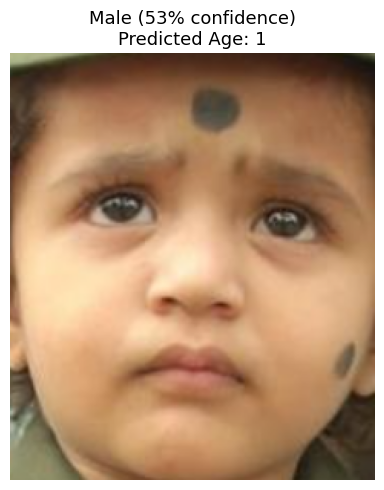

In [16]:
from google.colab import files
print("Upload a face image (jpg/png):")
uploaded = files.upload()
for fname in uploaded:
    predict(fname)

Upload a face image (jpg/png):


Saving Screenshot 2026-04-01 095812.png to Screenshot 2026-04-01 095812.png


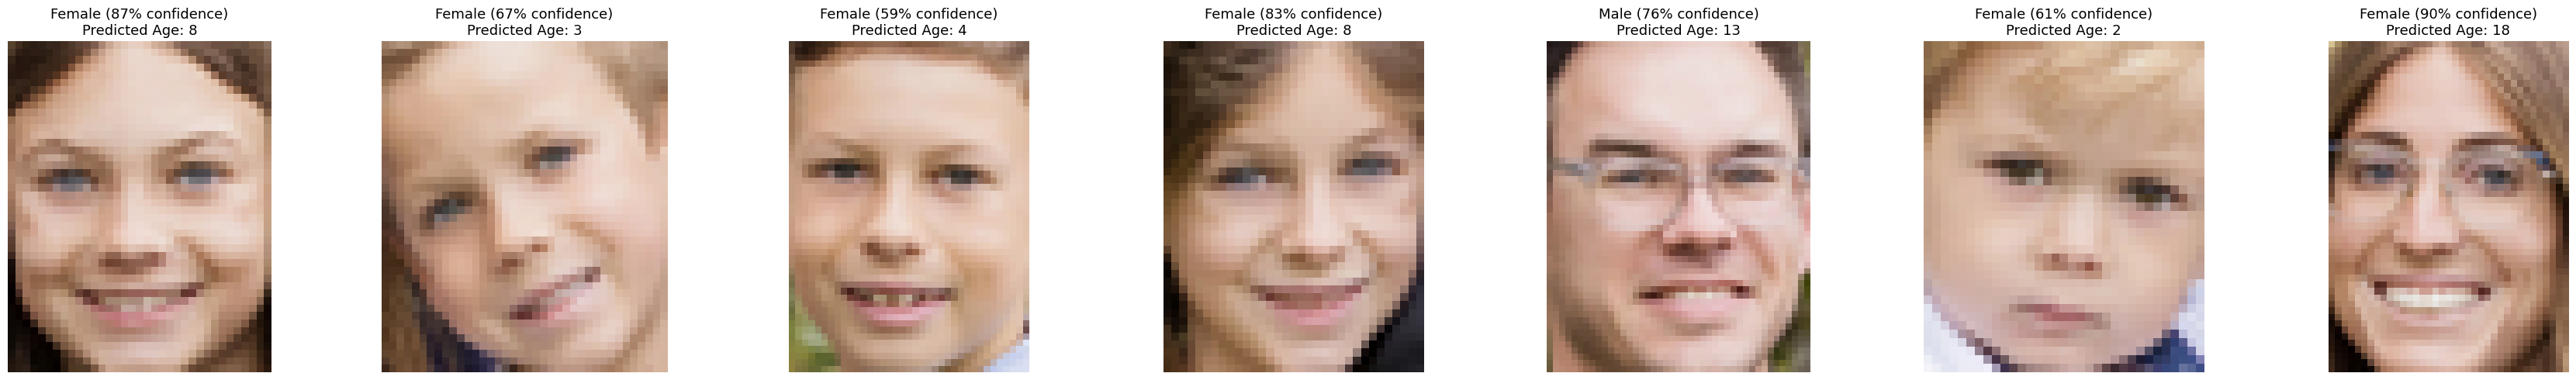

In [17]:
from google.colab import files
print("Upload a face image (jpg/png):")
uploaded = files.upload()
for fname in uploaded:
    predict(fname)

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("age_gender_model_v2.pth", "/content/drive/MyDrive/age_gender_model_v2.pth")


Mounted at /content/drive


'/content/drive/MyDrive/age_gender_model_v2.pth'